# M6 — Model Evaluation & Performance Analysis
**DR-Triage · Diabetic Retinopathy Stage Detection**

Covers rubric item 6 (*Model Evaluation & Performance Analysis*, 15 marks), on the
**held-out test split** (`outputs/splits/test.csv`) — never seen during training or
model selection.

Contents: training curves · headline metrics · per-class precision/recall/F1 ·
confusion matrices · **Quadratic Weighted Kappa** · ROC & PR curves + AUC ·
**referable-DR** sensitivity/specificity · **calibration + temperature scaling** ·
**MC-Dropout uncertainty** · **Grad-CAM++** · error analysis · softmax-vs-ordinal
head comparison.

All logic is in `src/evaluate.py`; figures are saved to `outputs/figures/`.

In [1]:
# --- Setup ---------------------------------------------------------------------
import sys, os, glob, shutil
from pathlib import Path

PROJECT = None
for cand in ["dr-triage", ".", "..", "/kaggle/working/dr-triage"]:
    if (Path(cand) / "src" / "data.py").is_file():
        PROJECT = str(Path(cand).resolve()); break
if PROJECT is None:
    hits = glob.glob("/kaggle/input/**/src/data.py", recursive=True)
    if hits:
        src_root = str(Path(hits[0]).parents[1]); PROJECT = "/kaggle/working/dr-triage"
        shutil.copytree(src_root, PROJECT, dirs_exist_ok=True)
assert PROJECT
os.chdir(PROJECT); sys.path.insert(0, PROJECT)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.data import load_config, load_splits, load_labels
from src.model import DRModel
from src import evaluate as E

cfg = load_config()
FIG = Path(cfg["paths"]["figures_dir"]); FIG.mkdir(parents=True, exist_ok=True)
MET = Path(cfg["paths"]["outputs"]) / "metrics"; MET.mkdir(parents=True, exist_ok=True)
CLASSES = cfg["classes"]
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

splits = None
try:
    splits = load_splits(cfg)
    test_df, val_df = splits["test"], splits["val"]
except FileNotFoundError:
    df = load_labels(cfg); test_df = val_df = df.sample(400, random_state=0).reset_index(drop=True)
print("test:", len(test_df), "| val:", len(val_df))

/Users/ilmeedesilva/Computer Vision/dr-triage/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps
test: 550 | val: 550


## 6.1  Load the trained ensemble

Loads `outputs/checkpoints/fold*_best.pt` from the M5 run (download them from your
Kaggle commit into that folder). If none are present the notebook still runs in
**DEMO mode** with one randomly-initialised model, so you can check every cell
works — the numbers are meaningless until real checkpoints are in place.

In [2]:
try:
    models = E.load_fold_models(cfg, device)
    DEMO = False
except FileNotFoundError as e:
    print("!! DEMO MODE:", e)
    models = [DRModel(cfg, pretrained=False).to(device).eval()]
    DEMO = True
TAG = "  [DEMO — random weights]" if DEMO else ""
print("ensemble size:", len(models), "| DEMO:", DEMO)

loaded 3 fold checkpoint(s): ['fold0_best.pt', 'fold1_best.pt', 'fold2_best.pt']
ensemble size: 3 | DEMO: False


## 6.2  Training curves (loss & QWK per epoch)

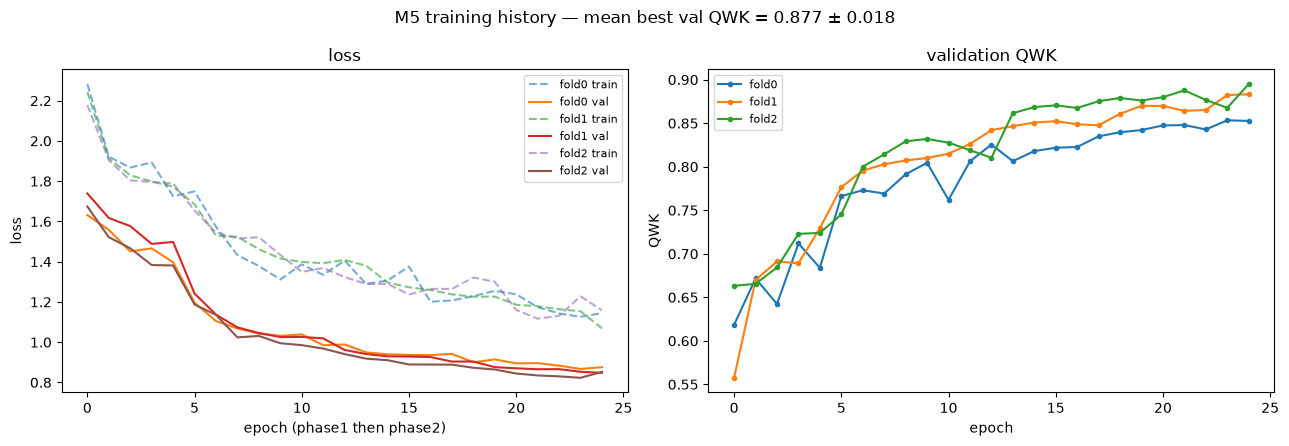

In [3]:
cv_path = MET / "cv_summary.json"
if cv_path.is_file():
    cv = json.loads(cv_path.read_text())
    folds = cv["folds"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for fr in folds:
        h = fr["history"]
        ep = range(len(h))
        axes[0].plot(ep, [r["train"]["loss"] for r in h], "--", alpha=.6, label=f"fold{fr['fold']} train")
        axes[0].plot(ep, [r["val"]["loss"] for r in h], "-", label=f"fold{fr['fold']} val")
        axes[1].plot(ep, [r["val"]["qwk"] for r in h], "-o", ms=3, label=f"fold{fr['fold']}")
    axes[0].set(title="loss", xlabel="epoch (phase1 then phase2)", ylabel="loss"); axes[0].legend(fontsize=8)
    axes[1].set(title="validation QWK", xlabel="epoch", ylabel="QWK"); axes[1].legend(fontsize=8)
    plt.suptitle(f"M5 training history — mean best val QWK = {cv['val_qwk_mean']:.3f} ± {cv['val_qwk_std']:.3f}")
    plt.tight_layout(); plt.savefig(FIG / "06_training_curves.png", dpi=150); plt.show()
else:
    print("cv_summary.json not found — run the FULL training in notebook 05 (or download it).")

## 6.3  Predictions on the held-out test set (ensemble + TTA)

In [4]:
pred = E.predict_split(models, test_df, cfg, device, tta=cfg["train"]["tta"])
from sklearn.metrics import accuracy_score, f1_score

acc = accuracy_score(pred["y_true"], pred["ord_pred"])
mf1 = f1_score(pred["y_true"], pred["stage_pred"], average="macro")
qwk_ord = E.qwk(pred["y_true"], pred["ord_pred"])
qwk_soft = E.qwk(pred["y_true"], pred["stage_pred"])
ref = E.referable_eval(pred["y_true"], pred["ref_prob"])
print(f"HEADLINE (test, n={len(test_df)}){TAG}")
print(f"  accuracy (ordinal head) : {acc:.3f}")
print(f"  macro-F1  (softmax head): {mf1:.3f}")
print(f"  QWK  ordinal head       : {qwk_ord:.3f}")
print(f"  QWK  softmax head       : {qwk_soft:.3f}")
print(f"  referable-DR AUC        : {ref['auc']:.3f}  (sens {ref['sensitivity']:.2f} / spec {ref['specificity']:.2f} @0.5)")

HEADLINE (test, n=550)
  accuracy (ordinal head) : 0.747
  macro-F1  (softmax head): 0.509
  QWK  ordinal head       : 0.854
  QWK  softmax head       : 0.838
  referable-DR AUC        : 0.979  (sens 0.93 / spec 0.91 @0.5)


## 6.4  Per-class precision / recall / F1

In [5]:
rep = E.per_class_report(pred["y_true"], pred["stage_pred"], CLASSES)
rep.to_csv(MET / "test_per_class.csv", index=False)
print(rep.round(3).to_string(index=False))

stage             name  precision  recall    f1  support
    0            No DR      0.977   0.937 0.957      271
    1             Mild      0.426   0.768 0.548       56
    2         Moderate      0.793   0.153 0.257      150
    3           Severe      0.183   0.793 0.297       29
    4 Proliferative DR      0.559   0.432 0.487       44
             macro avg      0.587   0.617 0.509      550
          weighted avg      0.795   0.658 0.652      550


## 6.5  Confusion matrices (raw & row-normalised)

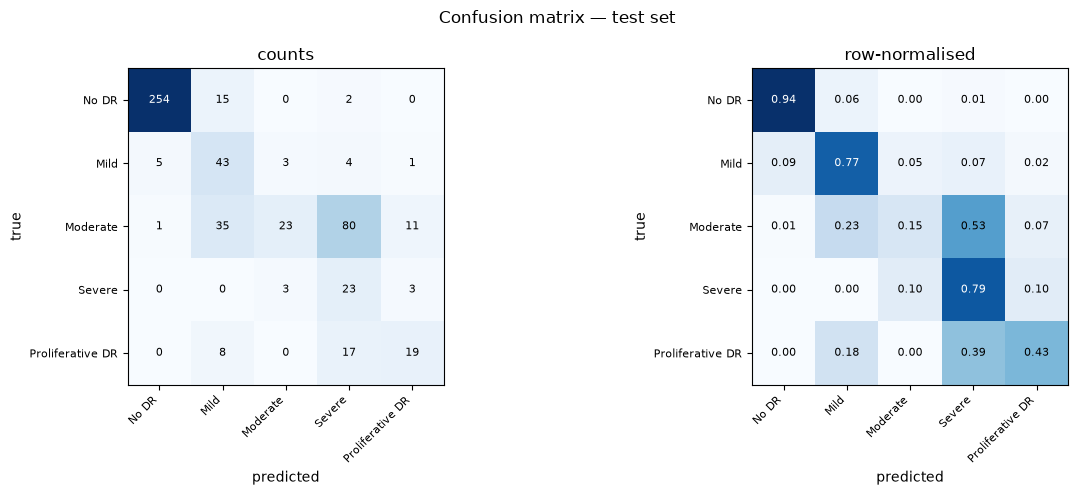

In [6]:
cm, cmn = E.confusion(pred["y_true"], pred["stage_pred"], len(CLASSES))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, M, title, fmt in [(axes[0], cm, "counts", "d"), (axes[1], cmn, "row-normalised", ".2f")]:
    im = ax.imshow(M, cmap="Blues"); ax.set_title(title)
    ax.set_xticks(range(len(CLASSES))); ax.set_yticks(range(len(CLASSES)))
    ax.set_xticklabels([CLASSES[k] for k in CLASSES], rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels([CLASSES[k] for k in CLASSES], fontsize=8)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j, i, format(M[i, j], fmt), ha="center", va="center",
                    color="white" if M[i, j] > M.max() * 0.6 else "black", fontsize=8)
plt.suptitle("Confusion matrix — test set" + TAG)
plt.tight_layout(); plt.savefig(FIG / "06_confusion.png", dpi=150); plt.show()

## 6.6  ROC & Precision-Recall curves (one-vs-rest per stage)

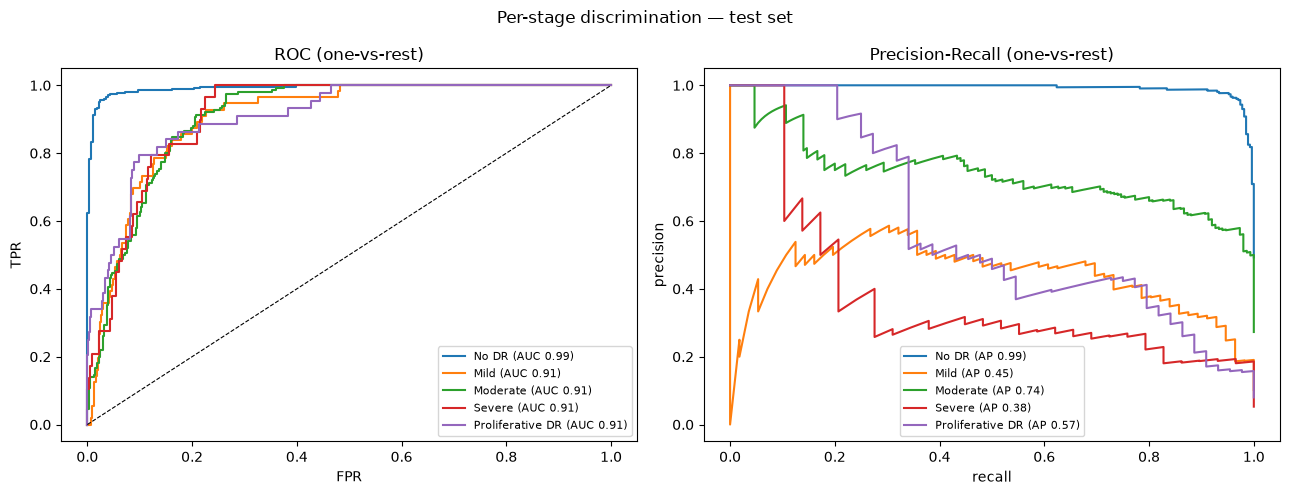

In [7]:
rp = E.ovr_roc_pr(pred["y_true"], pred["stage_probs"], len(CLASSES))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for k, d in rp.items():
    axes[0].plot(d["fpr"], d["tpr"], label=f"{CLASSES[k]} (AUC {d['auc']:.2f})")
    axes[1].plot(d["rec"], d["prec"], label=f"{CLASSES[k]} (AP {d['ap']:.2f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=.8); axes[0].set(title="ROC (one-vs-rest)", xlabel="FPR", ylabel="TPR")
axes[1].set(title="Precision-Recall (one-vs-rest)", xlabel="recall", ylabel="precision")
for a in axes: a.legend(fontsize=8)
plt.suptitle("Per-stage discrimination — test set" + TAG)
plt.tight_layout(); plt.savefig(FIG / "06_roc_pr.png", dpi=150); plt.show()

## 6.7  Referable-DR decision  (stage ≥ 2 → refer)

The single decision a screening clinic acts on. We sweep the operating point and
pick one that favours **sensitivity** (missing referable disease is the costly error).

 threshold  sensitivity  specificity
       0.3        0.978        0.856
       0.4        0.969        0.884
       0.5        0.933        0.911
       0.6        0.897        0.930
       0.7        0.843        0.957


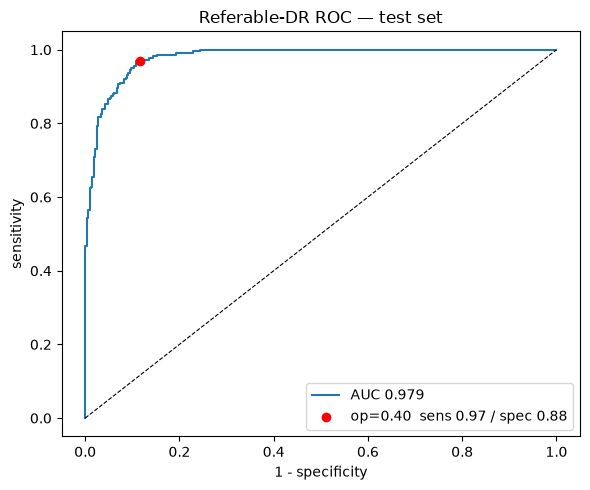

In [8]:
sweep = []
for op in [0.30, 0.40, 0.50, 0.60, 0.70]:
    r = E.referable_eval(pred["y_true"], pred["ref_prob"], operating_point=op)
    sweep.append({"threshold": op, "sensitivity": r["sensitivity"], "specificity": r["specificity"]})
print(pd.DataFrame(sweep).round(3).to_string(index=False))

r = E.referable_eval(pred["y_true"], pred["ref_prob"], operating_point=0.40)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(r["fpr"], r["tpr"], label=f"AUC {r['auc']:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=.8)
ax.scatter([1 - r["specificity"]], [r["sensitivity"]], c="red", zorder=5,
           label=f"op=0.40  sens {r['sensitivity']:.2f} / spec {r['specificity']:.2f}")
ax.set(title="Referable-DR ROC — test set" + TAG, xlabel="1 - specificity", ylabel="sensitivity")
ax.legend()
plt.tight_layout(); plt.savefig(FIG / "06_referable.png", dpi=150); plt.show()

## 6.8  Calibration & temperature scaling

Temperature `T` is fitted on the **validation** logits (never the test set), then
applied to test. A well-calibrated model's confidence matches its accuracy.

fitted T = 1.053   |   ECE  0.0876 -> 0.0786


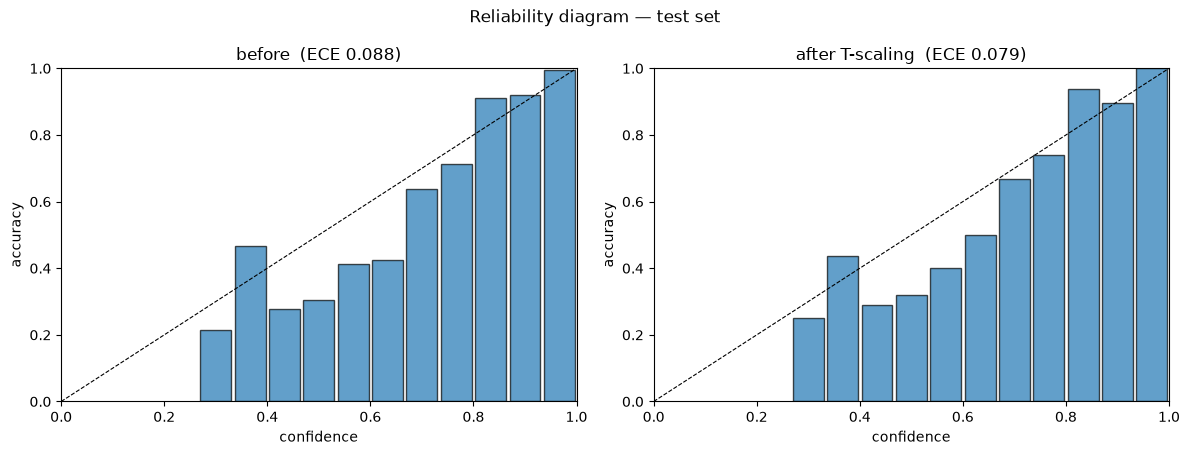

In [9]:
pv = E.predict_split(models, val_df, cfg, device, tta=False)
T = E.fit_temperature(pv["stage_logits"], pv["y_true"])
import torch.nn.functional as _F
probs_before = pred["stage_probs"]
probs_after = _F.softmax(torch.tensor(pred["stage_logits"]) / T, dim=1).numpy()
ece_b, bins_b = E.expected_calibration_error(probs_before, pred["y_true"])
ece_a, bins_a = E.expected_calibration_error(probs_after, pred["y_true"])
print(f"fitted T = {T:.3f}   |   ECE  {ece_b:.4f} -> {ece_a:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, bins, ece, ttl in [(axes[0], bins_b, ece_b, "before"), (axes[1], bins_a, ece_a, "after T-scaling")]:
    conf = [b[0] for b in bins]; acc = [b[1] for b in bins]
    ax.plot([0, 1], [0, 1], "k--", lw=.8)
    ax.bar(conf, acc, width=1/len(bins) * 0.9, alpha=.7, edgecolor="k")
    ax.set(title=f"{ttl}  (ECE {ece:.3f})", xlabel="confidence", ylabel="accuracy", xlim=(0, 1), ylim=(0, 1))
plt.suptitle("Reliability diagram — test set" + TAG)
plt.tight_layout(); plt.savefig(FIG / "06_calibration.png", dpi=150); plt.show()

## 6.9  Predictive uncertainty (Monte-Carlo dropout)

Keeping dropout active at inference and sampling 20 passes gives a per-image
uncertainty. Routing the least-confident cases to a human should raise accuracy on
the rest — evidence the uncertainty is meaningful.

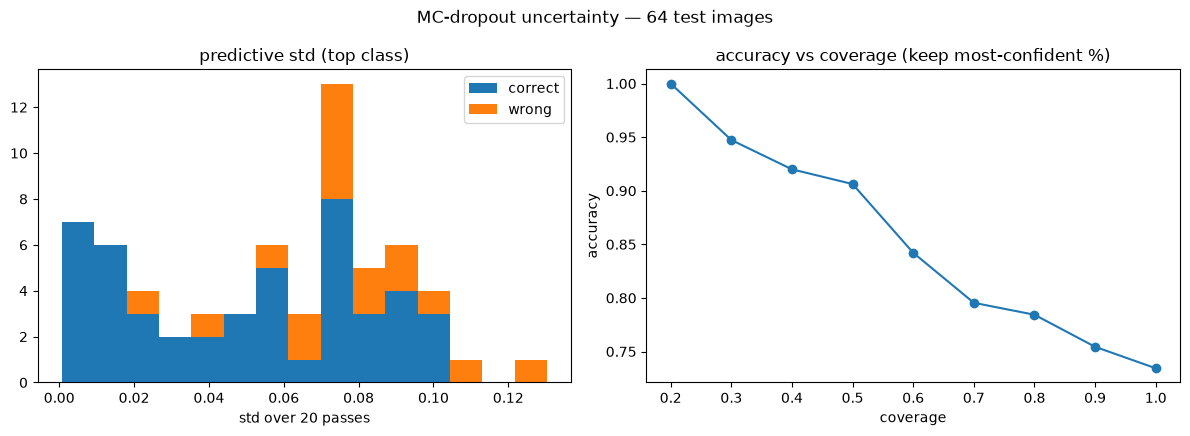

In [10]:
from src.augment import build_eval_aug
from src.preprocess import make_preprocessor
from src.data import APTOSDataset, DatasetConfig

sub = test_df.sample(min(64, len(test_df)), random_state=0).reset_index(drop=True)
ds = APTOSDataset(sub, DatasetConfig(image_size=cfg["image"]["size_stage2"],
                 preprocess=make_preprocessor(cfg),
                 transform=build_eval_aug(cfg["image"]["size_stage2"], cfg["image"]["mean"], cfg["image"]["std"])))
xb = torch.stack([ds[i][0] for i in range(len(ds))]).to(device)
mean_p, std_p, ent = E.mc_dropout_predict(models[0], xb, passes=20)
correct = (mean_p.argmax(1) == sub["stage"].to_numpy())

order = np.argsort(std_p)                       # most confident first
acc_at_coverage = [correct[order[:int(len(order) * c)]].mean() for c in np.linspace(.2, 1, 9)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].hist([std_p[correct], std_p[~correct]], bins=15, label=["correct", "wrong"], stacked=True)
axes[0].set(title="predictive std (top class)", xlabel="std over 20 passes"); axes[0].legend()
axes[1].plot(np.linspace(.2, 1, 9), acc_at_coverage, "-o")
axes[1].set(title="accuracy vs coverage (keep most-confident %)", xlabel="coverage", ylabel="accuracy")
plt.suptitle("MC-dropout uncertainty — 64 test images" + TAG)
plt.tight_layout(); plt.savefig(FIG / "06_uncertainty.png", dpi=150); plt.show()

## 6.10  Grad-CAM++ — where the model looks

Overlays for a few test images. On a trained model these should highlight
microaneurysms, haemorrhages and exudates near the macula rather than the optic
disc or background.

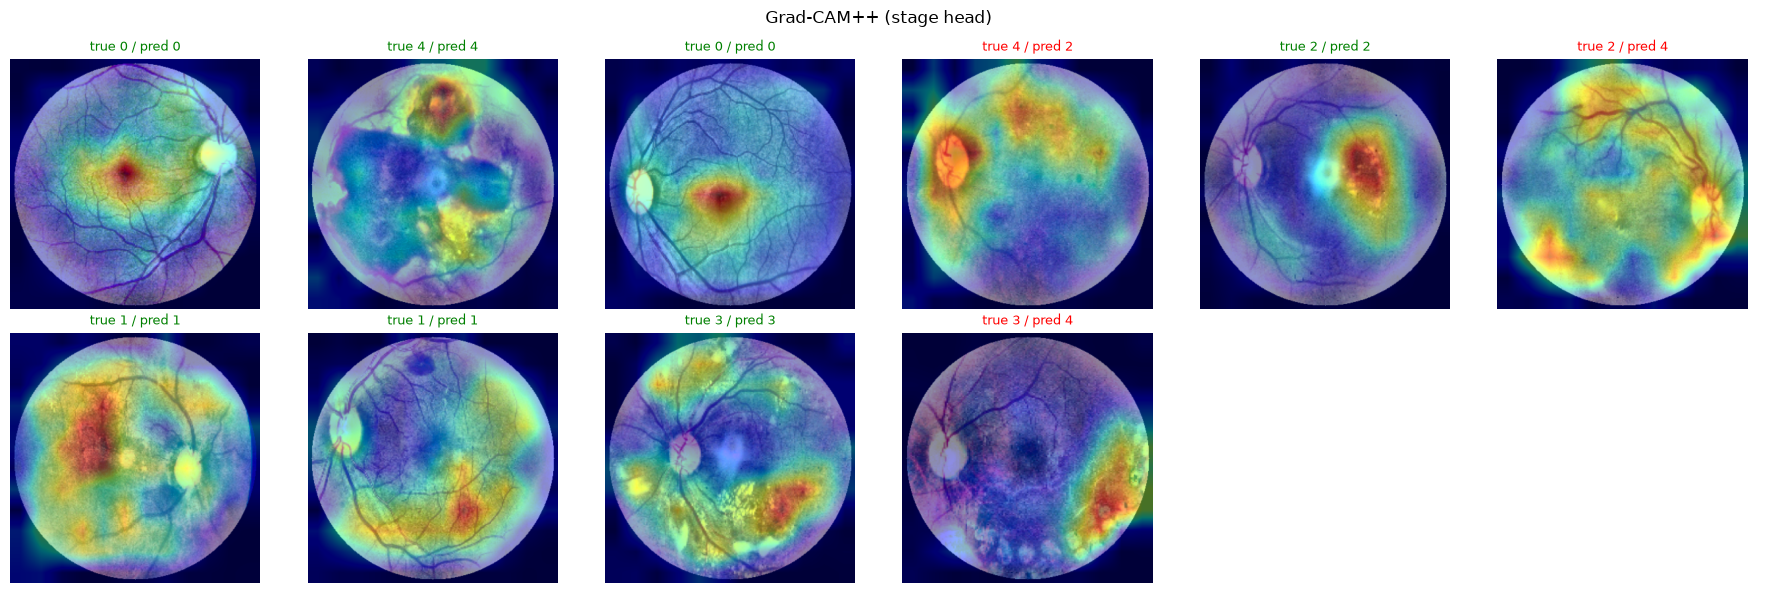

In [11]:
picks = test_df.groupby("stage", group_keys=False).head(2).reset_index(drop=True)
ds = APTOSDataset(picks, DatasetConfig(image_size=cfg["image"]["size_stage2"],
                 preprocess=make_preprocessor(cfg),
                 transform=build_eval_aug(cfg["image"]["size_stage2"], cfg["image"]["mean"], cfg["image"]["std"])))
imgs = torch.stack([ds[i][0] for i in range(len(ds))])
with torch.no_grad():
    p = models[0](imgs.to(device))["stage"].softmax(1).cpu().numpy()
cams = E.gradcam_plus_plus(models[0], imgs, p.argmax(1), device)

n = len(picks); cols = 6; rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
for i, ax in enumerate(axes.ravel()):
    if i >= n: ax.axis("off"); continue
    rgb = E.denormalize(imgs[i], cfg["image"]["mean"], cfg["image"]["std"])
    ax.imshow(rgb); ax.imshow(cams[i], cmap="jet", alpha=0.45)
    t, pr = int(picks.iloc[i]["stage"]), int(p[i].argmax())
    ax.set_title(f"true {t} / pred {pr}", fontsize=9,
                 color="green" if t == pr else "red"); ax.axis("off")
plt.suptitle("Grad-CAM++ (stage head)" + TAG)
plt.tight_layout(); plt.savefig(FIG / "06_gradcam.png", dpi=150, bbox_inches="tight"); plt.show()

## 6.11  Error analysis — the worst misclassifications

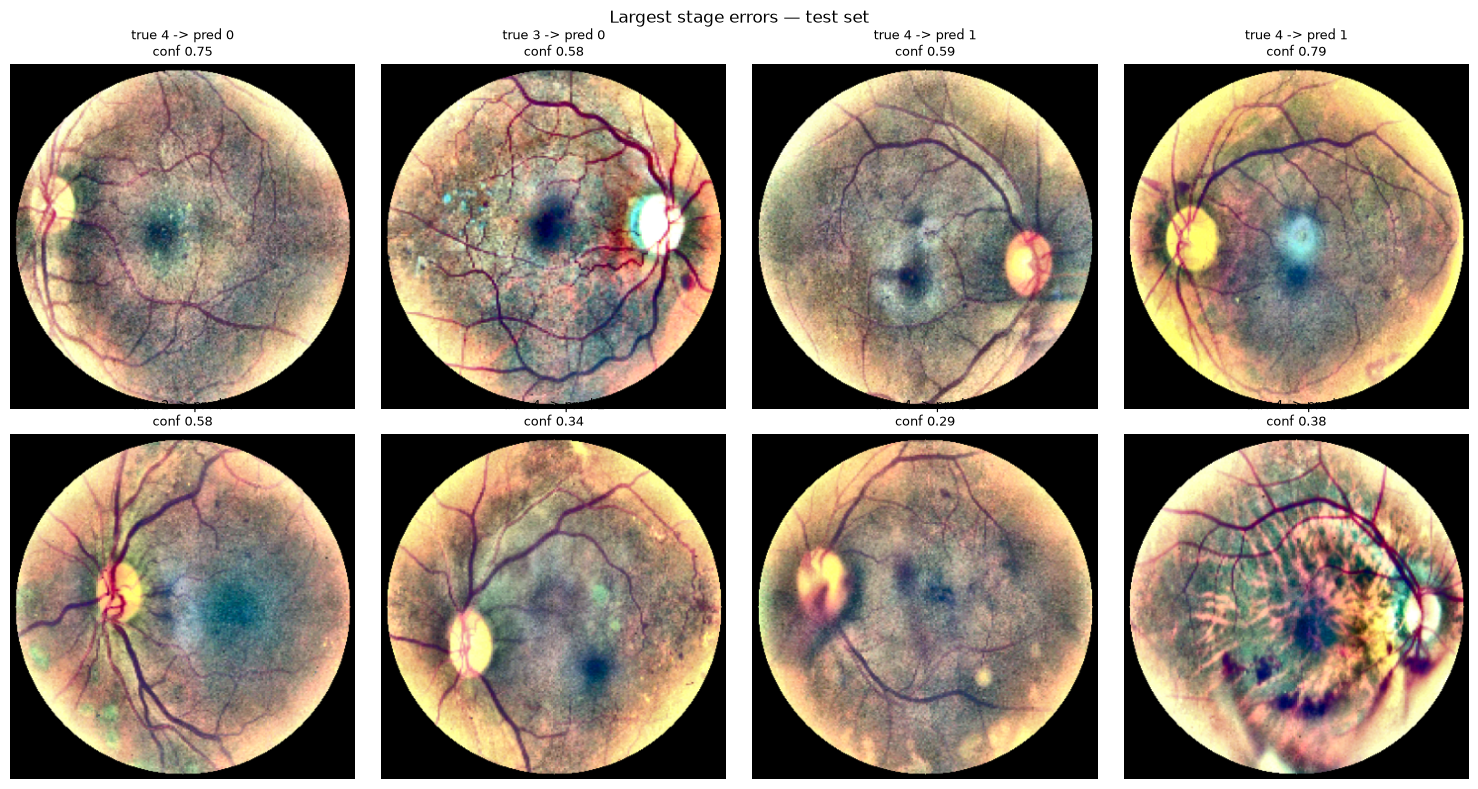

Common causes to check: borderline Mild/Moderate grades, low image quality, off-centre macula, and rare Severe/Proliferative under-representation.


In [12]:
dist = np.abs(pred["ord_pred"] - pred["y_true"])
worst = np.argsort(-dist)[:8]
ds = APTOSDataset(test_df.iloc[worst].reset_index(drop=True),
                 DatasetConfig(image_size=cfg["image"]["size_stage2"],
                 preprocess=make_preprocessor(cfg),
                 transform=build_eval_aug(cfg["image"]["size_stage2"], cfg["image"]["mean"], cfg["image"]["std"])))
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for ax, idx in zip(axes.ravel(), range(len(worst))):
    w = worst[idx]
    ax.imshow(E.denormalize(ds[idx][0], cfg["image"]["mean"], cfg["image"]["std"]))
    ax.set_title(f"true {int(pred['y_true'][w])} -> pred {int(pred['ord_pred'][w])}\n"
                 f"conf {pred['stage_probs'][w].max():.2f}", fontsize=9); ax.axis("off")
plt.suptitle("Largest stage errors — test set" + TAG)
plt.tight_layout(); plt.savefig(FIG / "06_errors.png", dpi=150, bbox_inches="tight"); plt.show()
print("Common causes to check: borderline Mild/Moderate grades, low image quality, "
      "off-centre macula, and rare Severe/Proliferative under-representation.")

## 6.12  Softmax head vs ordinal head

In [13]:
import pandas as pd
rows = []
for name, yp in [("softmax", pred["stage_pred"]), ("ordinal (CORAL)", pred["ord_pred"])]:
    rows.append({"head": name,
                 "accuracy": accuracy_score(pred["y_true"], yp),
                 "QWK": E.qwk(pred["y_true"], yp),
                 "macro_F1": f1_score(pred["y_true"], yp, average="macro"),
                 "mean |err|": float(np.abs(yp - pred["y_true"]).mean())})
cmp = pd.DataFrame(rows)
print(cmp.round(3).to_string(index=False))
cmp.to_csv(MET / "test_head_comparison.csv", index=False)
print("\nExpectation: the ordinal head gives higher QWK / lower mean |err| because "
      "it is trained to respect stage order; the softmax head can give slightly higher "
      "raw accuracy. Report both and use the ordinal head as the primary predictor.")

           head  accuracy   QWK  macro_F1  mean |err|
        softmax     0.658 0.838     0.509       0.411
ordinal (CORAL)     0.747 0.854     0.501       0.322

Expectation: the ordinal head gives higher QWK / lower mean |err| because it is trained to respect stage order; the softmax head can give slightly higher raw accuracy. Report both and use the ordinal head as the primary predictor.


## 6.13  Interpretation  *(report-ready)*

Fill in with your real numbers once the trained checkpoints are in place:

- **Headline:** test QWK ≈ __ (ordinal head), macro-F1 ≈ __, referable-DR AUC ≈ __
  with sensitivity __ / specificity __ at the chosen operating point.
- **Confusion matrix:** most errors are between *adjacent* stages (e.g. Mild↔Moderate),
  which the quadratic weighting in QWK penalises only lightly — clinically the model
  rarely confuses "no referral" with "urgent".
- **Calibration:** raw ECE __ → __ after temperature scaling (T = __); predicted
  probabilities can be reported to clinicians as trustworthy confidences.
- **Uncertainty:** deferring the least-confident __% of cases raises accuracy on the
  remainder from __ to __ — a practical human-in-the-loop safeguard.
- **Grad-CAM++:** attention concentrates on __ (lesions / macula / optic disc), which
  __ supports / does not fully support the prediction being lesion-driven.
- **Limitations:** single-population dataset, 224-px source resolution, rare-class
  support, and no external validation set.

## Milestone status
- [x] M1–M5 complete
- [x] **M6 — evaluation** (`src/evaluate.py`), figures in `outputs/figures/`
- [ ] M7 — image-quality gate + RetinaBot chatbot → `notebooks/07_app_demo.ipynb`